# Module 6: MLOps — Taking ML Models to Production
## Enterprise Use Case: Deploying the Churn Prediction Model

---

> **Series:** Fine-Tuning & ML Fundamentals — From Zero to Enterprise  
> **Module:** 6 of 6 (Final Module)  
> **Prerequisites:** Modules 1–5 completed  
> **Time to complete:** ~2–3 hours

---

## What This Module Covers

| Topic | Tool / Concept |
|---|---|
| Experiment Tracking | MLflow |
| Model Versioning | MLflow Model Registry |
| Model Serving | FastAPI REST API |
| Monitoring & Drift Detection | KS Test, Performance Monitoring |
| CI/CD for ML | GitHub Actions, A/B Testing |

**Business context:** You built the churn prediction model in Module 1. Now the business wants it running in production, reliably, with alerts when it degrades. That is what MLOps solves.

In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print(f"mlflow {mlflow.__version__}")
print("Setup complete")

mlflow 3.12.0
Setup complete


---

# Lesson 1: What Is MLOps?

## The One-Line Definition

**MLOps = DevOps for Machine Learning.**

DevOps solved the problem of "it works on my laptop but breaks in production" for software engineers. MLOps solves the exact same problem for machine learning models — plus several problems that are unique to ML.

## The Problem MLOps Solves

Imagine this scenario (it happens at almost every company that starts using ML):

1. A data scientist trains a churn model in a Jupyter notebook. It achieves 82% AUC. Everyone is excited.
2. Three months later, a software engineer tries to deploy it. The model file is on the data scientist's laptop. Nobody knows which version of Python or scikit-learn was used.
3. It finally gets deployed. Six months later, churn starts rising — the model silently started making bad predictions because the customer base changed, but nobody was watching it.
4. The business asks "can we go back to the old model?" Nobody knows which one the "old model" was.

**MLOps prevents every step of that disaster.**

## The 5 Pillars of MLOps

| Pillar | What It Does | Why It Matters |
|---|---|---|
| **1. Experiment Tracking** | Log every training run: params, metrics, model files | Never lose a good model. Always reproducible. |
| **2. Model Registry** | Version your models like code (v1, v2, Staging, Production) | Know exactly what is live and roll back instantly |
| **3. Model Serving** | Expose models as REST APIs | Other apps (CRM, mobile, web) can call your model |
| **4. Monitoring** | Watch model performance in production over time | Catch degradation before customers do |
| **5. CI/CD for ML** | Automate retraining, evaluation, and promotion | No human bottleneck in the pipeline |

## The Full MLOps Loop

```
┌─────────────────────────────────────────────────────────────────────┐
│                        THE MLOPS LOOP                               │
│                                                                     │
│  Developer Laptop                                                   │
│  (notebooks, EDA)  ──►  MLflow Tracking  ──►  Model Registry       │
│        │                (experiments,          (v1 Staging,         │
│        │                 params, metrics)       v2 Production)      │
│        │                                              │             │
│        │                                              ▼             │
│  Retrain Trigger   ◄──  Monitoring        ◄──  Serving API          │
│  (drift detected)       (AUC, drift,           (FastAPI /predict)   │
│                          alerts)                     │             │
│                                                       ▼             │
│                                                  Production         │
│                                                  (CRM, mobile,      │
│                                                   dashboards)       │
└─────────────────────────────────────────────────────────────────────┘
```

The loop never stops. The model is always being watched, and when it degrades, the pipeline automatically retrains and redeploys.

---

# Lesson 2: Why MLOps Matters — What Goes Wrong Without It

These are real problems that happen at companies without MLOps practices. Every row in this table is a true story from somewhere.

| Situation | Without MLOps | Consequence |
|---|---|---|
| "Which hyperparameters produced my best model?" | No experiment log exists | Cannot reproduce the result. The model is a black box. |
| "The model worked in testing but fails in prod" | No environment tracking (Python version, library versions) | Hours or days of debugging environment mismatches |
| "We need to roll back to last week's model" | No model versioning | Impossible. The old model is gone. |
| "The data scientists use Python 3.8 but prod runs 3.11" | No containerisation or dependency management | Crashes in production, pickled models fail to load |
| "Churn accuracy dropped from 82% to 67% last month" | No monitoring | Found by the business team after months of bad decisions |
| "Who approved this model going to production?" | No approval workflow | Audit failure, regulatory risk |
| "The model is biased against certain age groups" | No fairness monitoring | PR crisis, legal liability |
| "Retraining the model takes 2 weeks of manual work" | No automated pipeline | Slow response to data drift |

## The Cost of Not Doing MLOps

A study by Gartner found that **85% of ML projects never make it to production**. The technical work of building the model is maybe 20% of the total effort. The remaining 80% is infrastructure, deployment, monitoring, and maintenance — which is exactly what MLOps addresses.

If you can talk confidently about MLOps in an interview, you immediately stand out from candidates who can only talk about model accuracy.

In [2]:
# Recreate the exact same churn dataset from Module 1
# Same seed, same features, same logic — so our MLOps pipeline is for a real model
np.random.seed(42)
n = 5000

tenure       = np.random.randint(1, 72, size=n)
monthly      = np.random.uniform(20, 120, size=n)
age          = np.random.randint(18, 75, size=n)
support_calls= np.random.poisson(lam=2, size=n)
outages      = np.random.poisson(lam=1, size=n)

contract = np.random.choice(
    ['Month-to-Month', 'One-Year', 'Two-Year'],
    size=n, p=[0.55, 0.25, 0.20]
)
payment = np.random.choice(
    ['Electronic Check', 'Mailed Check', 'Bank Transfer', 'Credit Card'],
    size=n, p=[0.35, 0.25, 0.20, 0.20]
)
has_streaming = np.random.choice([0, 1], size=n, p=[0.45, 0.55])
has_security  = np.random.choice([0, 1], size=n, p=[0.60, 0.40])

churn_prob = (
    0.10
    + 0.30 * (contract == 'Month-to-Month')
    - 0.15 * (contract == 'Two-Year')
    + 0.005 * support_calls
    + 0.05  * outages
    - 0.003 * tenure
    + 0.002 * monthly
    - 0.05  * has_security
    + 0.10  * (payment == 'Electronic Check')
)
churn_prob   = np.clip(churn_prob, 0.02, 0.95)
churn        = (np.random.rand(n) < churn_prob).astype(int)
total_charges= tenure * monthly * np.random.uniform(0.95, 1.05, size=n)

df = pd.DataFrame({
    'customer_id':         [f'CUST_{i:05d}' for i in range(n)],
    'tenure_months':       tenure,
    'monthly_charges':     monthly.round(2),
    'total_charges':       total_charges.round(2),
    'num_support_calls':   support_calls,
    'num_service_outages': outages,
    'age':                 age,
    'contract_type':       contract,
    'payment_method':      payment,
    'has_streaming':       has_streaming,
    'has_security_addon':  has_security,
    'churn':               churn
})

# Preprocess identically to Module 1
df_ml      = df.drop(columns=['customer_id'])
df_encoded = pd.get_dummies(df_ml, columns=['contract_type', 'payment_method'], drop_first=False)

X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)

print(f"Dataset shape : {df.shape}")
print(f"Train / Test  : {X_train.shape[0]} / {X_test.shape[0]}")
print(f"Churn rate    : {y.mean()*100:.1f}%")
print(f"Features      : {list(X.columns)}")

Dataset shape : (5000, 12)
Train / Test  : 4000 / 1000
Churn rate    : 35.1%
Features      : ['tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'num_service_outages', 'age', 'has_streaming', 'has_security_addon', 'contract_type_Month-to-Month', 'contract_type_One-Year', 'contract_type_Two-Year', 'payment_method_Bank Transfer', 'payment_method_Credit Card', 'payment_method_Electronic Check', 'payment_method_Mailed Check']


---

# Lesson 3: Experiment Tracking with MLflow

## The Problem Without Experiment Tracking

Imagine you train 20 different model variants over two weeks — different algorithms, different hyperparameters. You find one that works great. Three days later, you cannot remember which one it was. You did not write down the exact settings. This happens to every data scientist working without experiment tracking.

## What MLflow Does

MLflow is the most popular open-source experiment tracking tool (used at Databricks, Airbnb, Facebook, and thousands of companies). Every time you train a model, you "log" everything about it:

```
with mlflow.start_run():
    mlflow.log_param("n_estimators", 200)   # hyperparameters you chose
    mlflow.log_metric("auc", 0.84)          # performance results
    mlflow.sklearn.log_model(model, "model") # the model file itself
```

Later you can browse all runs, compare them, and load any model from any run.

## Key Concepts

| Concept | What It Is | Analogy |
|---|---|---|
| **Experiment** | A named collection of related runs | A "project folder" |
| **Run** | One training session with specific settings | One "attempt" at training |
| **Parameters** | The hyperparameters you chose | The recipe ingredients |
| **Metrics** | The performance numbers (AUC, accuracy) | How the dish tasted |
| **Artifacts** | Files saved by the run (model, plots) | The actual dish you made |
| **Model Registry** | Versioned store of promoted models | The approved menu |

## Local Tracking (No Server Needed)

For this notebook, we use file-based local tracking:
```python
mlflow.set_tracking_uri('mlruns')  # saves everything to ./mlruns folder
```

In production, you would point this at a central MLflow server so the whole team shares the same experiment history.

In [3]:
# Set up local MLflow tracking
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('churn_prediction')

# Define 4 model variants to compare
experiments_config = [
    {
        'name': 'LogReg_C0.1',
        'model_type': 'LogisticRegression',
        'model': LogisticRegression(C=0.1, max_iter=1000, random_state=42),
        'params': {'C': 0.1, 'max_iter': 1000},
        'use_scaled': True
    },
    {
        'name': 'LogReg_C1.0',
        'model_type': 'LogisticRegression',
        'model': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
        'params': {'C': 1.0, 'max_iter': 1000},
        'use_scaled': True
    },
    {
        'name': 'RF_100_d5',
        'model_type': 'RandomForest',
        'model': RandomForestClassifier(n_estimators=100, max_depth=5, n_jobs=-1, random_state=42),
        'params': {'n_estimators': 100, 'max_depth': 5},
        'use_scaled': False
    },
    {
        'name': 'RF_200_d10',
        'model_type': 'RandomForest',
        'model': RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42),
        'params': {'n_estimators': 200, 'max_depth': 10},
        'use_scaled': False
    },
]

run_ids = []

for cfg in experiments_config:
    X_tr = X_train_sc if cfg['use_scaled'] else X_train.values
    X_te = X_test_sc  if cfg['use_scaled'] else X_test.values

    cfg['model'].fit(X_tr, y_train)
    preds = cfg['model'].predict(X_te)
    probs = cfg['model'].predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    f1  = f1_score(y_test, preds)

    with mlflow.start_run(run_name=cfg['name']) as run:
        # Log parameters
        mlflow.log_param('model_type', cfg['model_type'])
        mlflow.log_param('scaled_features', cfg['use_scaled'])
        for k, v in cfg['params'].items():
            mlflow.log_param(k, v)

        # Log metrics
        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('auc', auc)
        mlflow.log_metric('f1', f1)

        # Log the model as an artifact
        mlflow.sklearn.log_model(cfg['model'], artifact_path='model')

        run_ids.append(run.info.run_id)
        cfg['run_id'] = run.info.run_id
        cfg['metrics'] = {'accuracy': acc, 'auc': auc, 'f1': f1}

    print(f"  {cfg['name']:<15}  acc={acc:.4f}  auc={auc:.4f}  f1={f1:.4f}  run_id={run.info.run_id[:8]}...")

# Retrieve all runs from MLflow and sort by AUC
runs_df = mlflow.search_runs(
    experiment_names=['churn_prediction'],
    order_by=['metrics.auc DESC']
)

display_cols = ['tags.mlflow.runName', 'params.model_type', 'params.C',
                'params.n_estimators', 'params.max_depth',
                'metrics.accuracy', 'metrics.auc', 'metrics.f1']
display_cols = [c for c in display_cols if c in runs_df.columns]

print("\nAll runs sorted by AUC (best first):")
print(runs_df[display_cols].to_string(index=False))

best_row   = runs_df.iloc[0]
best_run_id= best_row['run_id']
best_name  = best_row.get('tags.mlflow.runName', 'unknown')
best_auc   = best_row['metrics.auc']
print(f"\nBest run: '{best_name}'  AUC={best_auc:.4f}  run_id={best_run_id[:12]}...")

2026/05/24 18:52:52 INFO mlflow.tracking.fluent: Experiment with name 'churn_prediction' does not exist. Creating a new experiment.


2026/05/24 18:52:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/24 18:52:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/24 18:53:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/24 18:53:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/05/24 18:53:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RF_100_d5        acc=0.7080  auc=0.7780  f1=0.5117  run_id=6d0d543f...


2026/05/24 18:53:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/24 18:53:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RF_200_d10       acc=0.7160  auc=0.7710  f1=0.5576  run_id=b8db57ca...

All runs sorted by AUC (best first):
tags.mlflow.runName  params.model_type params.C params.n_estimators params.max_depth  metrics.accuracy  metrics.auc  metrics.f1
        LogReg_C1.0 LogisticRegression      1.0                None             None             0.716     0.787282    0.552050
        LogReg_C0.1 LogisticRegression      0.1                None             None             0.717     0.787247    0.551506
          RF_100_d5       RandomForest     None                 100                5             0.708     0.777953    0.511706
         RF_200_d10       RandomForest     None                 200               10             0.716     0.770965    0.557632

Best run: 'LogReg_C1.0'  AUC=0.7873  run_id=11dd9253402a...


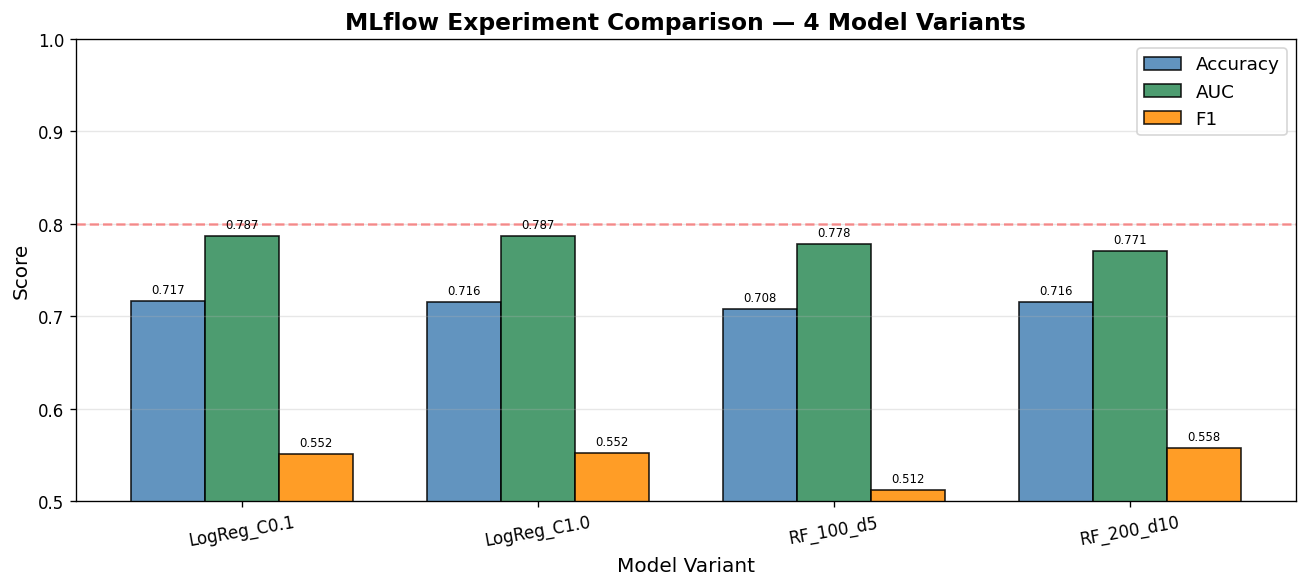

Winner: LogReg_C1.0 with AUC=0.7873
Why: AUC is the best single metric for a ranking/classification task like churn.
     It measures how well the model separates churners from non-churners across ALL thresholds.


In [4]:
# Visualise experiment comparison — grouped bar chart
model_names  = [cfg['name'] for cfg in experiments_config]
accuracies   = [cfg['metrics']['accuracy'] for cfg in experiments_config]
aucs         = [cfg['metrics']['auc'] for cfg in experiments_config]
f1s          = [cfg['metrics']['f1'] for cfg in experiments_config]

x      = np.arange(len(model_names))
width  = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='steelblue',  alpha=0.85, edgecolor='black')
bars2 = ax.bar(x,          aucs,       width, label='AUC',      color='seagreen',   alpha=0.85, edgecolor='black')
bars3 = ax.bar(x + width,  f1s,        width, label='F1',       color='darkorange', alpha=0.85, edgecolor='black')

ax.set_xlabel('Model Variant', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('MLflow Experiment Comparison — 4 Model Variants', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.4, label='0.80 threshold')

for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('experiment_comparison.png')
plt.show()

winner_idx  = int(np.argmax(aucs))
winner_name = model_names[winner_idx]
winner_auc  = aucs[winner_idx]
print(f"Winner: {winner_name} with AUC={winner_auc:.4f}")
print(f"Why: AUC is the best single metric for a ranking/classification task like churn.")
print(f"     It measures how well the model separates churners from non-churners across ALL thresholds.")

---

# Lesson 4: Model Versioning and the Model Registry

## What Is the Model Registry?

Think of the Model Registry as **GitHub for trained models**. Just like code has versions (v1.0, v1.1, v2.0) and branches (dev, staging, main), the Model Registry gives your models the same lifecycle management.

After you find the best model in your experiments, you "register" it. From that point, the model goes through formal stages before it can affect real users.

## The Model Lifecycle Stages

```
DEVELOPMENT          STAGING              PRODUCTION         ARCHIVED

  [Experiment]  ──►  [v1 Staging]  ──►  [v1 Production]  ──►  [v1 Archived]
                           │                    │
  [Experiment]  ──►  [v2 Staging]  ──►  [v2 Production]  ──►  [v2 Archived]
  (retrain)          (being tested)      (serving users)      (history kept)
                           │
  [Experiment]  ──►  [v3 Staging]  ← you are here
  (new features)     (testing now)
```

At any moment you can have:
- **v3 in Staging** — being evaluated on held-out data, A/B tested
- **v2 in Production** — serving all real users right now
- **v1 Archived** — kept forever for audit and rollback purposes

## Why This Is Important

| Scenario | Without Registry | With Registry |
|---|---|---|
| Prod model fails badly | No rollback possible — start from scratch | `promote(v1, Production)` — done in seconds |
| Audit: "who approved this model?" | Unknown | Full history: who promoted it, when, what metrics |
| "What changed between v1 and v2?" | Lost in emails | Registry shows all param/metric differences |
| Multiple teams deploying models | Chaos, version conflicts | One source of truth for every team |

In [5]:
# Register the best model and version it in the Model Registry
mlflow.set_tracking_uri('mlruns')
client = mlflow.tracking.MlflowClient()

# Find the best run by AUC
runs_df = mlflow.search_runs(
    experiment_names=['churn_prediction'],
    order_by=['metrics.auc DESC']
)
best_run_id = runs_df.iloc[0]['run_id']
best_auc    = runs_df.iloc[0]['metrics.auc']
best_acc    = runs_df.iloc[0]['metrics.accuracy']
best_f1     = runs_df.iloc[0]['metrics.f1']
run_name    = runs_df.iloc[0].get('tags.mlflow.runName', 'best_run')

print(f"Best run: {run_name}")
print(f"  run_id   : {best_run_id}")
print(f"  AUC      : {best_auc:.4f}")
print(f"  Accuracy : {best_acc:.4f}")
print(f"  F1       : {best_f1:.4f}")

# Register the model from the best run's artifacts
model_uri = f"runs:/{best_run_id}/model"
registered = mlflow.register_model(model_uri=model_uri, name='ChurnPredictor')
model_version = registered.version

print(f"\nRegistered as 'ChurnPredictor' version {model_version}")

# Transition to Production stage
client.transition_model_version_stage(
    name='ChurnPredictor',
    version=model_version,
    stage='Production'
)
print(f"Transitioned ChurnPredictor v{model_version} --> Production")

# Verify by loading the production model from the registry
prod_model = mlflow.sklearn.load_model(f'models:/ChurnPredictor/Production')
print(f"\nLoaded production model: {type(prod_model).__name__}")

# Make a test prediction with the loaded model
sample      = X_test.iloc[:3].values
sample_sc   = X_test_sc[:3]

# Use the correct input format (scaled vs unscaled) based on model type
model_type_str = type(prod_model).__name__
if 'Logistic' in model_type_str:
    test_input = sample_sc
else:
    test_input = sample

test_preds = prod_model.predict_proba(test_input)[:, 1]
print(f"\nTest predictions from production model:")
for i, prob in enumerate(test_preds):
    risk = 'HIGH' if prob > 0.6 else 'MEDIUM' if prob > 0.35 else 'LOW'
    print(f"  Customer {i+1}: churn probability = {prob:.3f}  ({risk} risk)")

# Show registry metadata
prod_versions = client.get_latest_versions('ChurnPredictor', stages=['Production'])
v = prod_versions[0]
print(f"\nModel Registry Entry:")
print(f"  Name    : {v.name}")
print(f"  Version : {v.version}")
print(f"  Stage   : {v.current_stage}")
print(f"  Run ID  : {v.run_id}")

Successfully registered model 'ChurnPredictor'.
2026/05/24 18:53:11 WARNING mlflow.tracking._model_registry.fluent: Run with id 11dd9253402a42d1a17d3d2d43d1d569 has no artifacts at artifact path 'model', registering model based on models:/m-653508f5ebc14a438e4b7642f6725409 instead


Best run: LogReg_C1.0
  run_id   : 11dd9253402a42d1a17d3d2d43d1d569
  AUC      : 0.7873
  Accuracy : 0.7160
  F1       : 0.5521

Registered as 'ChurnPredictor' version 1
Transitioned ChurnPredictor v1 --> Production

Loaded production model: LogisticRegression

Test predictions from production model:
  Customer 1: churn probability = 0.041  (LOW risk)
  Customer 2: churn probability = 0.437  (MEDIUM risk)
  Customer 3: churn probability = 0.070  (LOW risk)

Model Registry Entry:
  Name    : ChurnPredictor
  Version : 1
  Stage   : Production
  Run ID  : 11dd9253402a42d1a17d3d2d43d1d569


Created version '1' of model 'ChurnPredictor'.


---

# Lesson 5: Model Serving — Making Models Accessible to the World

## The Problem

A trained model sitting in an `.pkl` file on a data scientist's laptop is completely useless to the rest of the company. The CRM system cannot call a pickle file. The mobile app cannot import scikit-learn. The retention team's dashboard cannot run Python.

**Model serving** wraps your model in a REST API — a standard interface that any system in the world can call, regardless of what language or framework it uses.

## What Happens When You Call the API

```
CRM System                   Your Model API               MLflow Registry
    │                              │                            │
    │  POST /predict               │                            │
    │  {tenure: 3, charges: 95..}  │                            │
    │ ────────────────────────►    │  load_model('Production')  │
    │                              │ ─────────────────────────► │
    │                              │ ◄───────────────── model   │
    │                              │  preprocess → predict      │
    │  {churn_prob: 0.73,          │                            │
    │   risk: "HIGH"}              │                            │
    │ ◄────────────────────────    │                            │
    │                              │                            │
```

The whole roundtrip takes ~5 milliseconds. The CRM system gets a churn probability and shows it to the retention agent in real time.

## Two Common Approaches

**1. MLflow built-in serving** (quick, for internal use):
```bash
mlflow models serve -m models:/ChurnPredictor/Production --port 5000
```
One command and you have an API. Good for prototyping, not great for custom logic.

**2. FastAPI** (professional, production-grade):
- Full control over input validation, preprocessing, response format
- Automatic documentation at `/docs`
- Used at Uber, Netflix, Microsoft and thousands of companies
- 10x faster than Flask for high-throughput APIs

In [6]:
# FastAPI serving code — complete, production-ready implementation
# NOTE: We define the app here but do NOT start the server.
# To run it: save this code to app.py, then:
#   pip install fastapi uvicorn
#   uvicorn app:app --host 0.0.0.0 --port 8000

fastapi_code = '''
# app.py — ChurnPredictor API
# Run with: uvicorn app:app --host 0.0.0.0 --port 8000

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# ── App definition ───────────────────────────────────────────────────
app = FastAPI(
    title="Churn Predictor API",
    description="Real-time churn prediction for TeleNova customers",
    version="1.0"
)

# ── Load model at startup (once, not per request) ────────────────────
mlflow.set_tracking_uri("mlruns")
MODEL = mlflow.sklearn.load_model("models:/ChurnPredictor/Production")
SCALER = joblib.load("scaler.pkl")  # saved during training
MODEL_VERSION = "1.0"

# ── Request schema ───────────────────────────────────────────────────
class CustomerFeatures(BaseModel):
    customer_id:               str   = Field(..., example="CUST_00123")
    tenure_months:             float = Field(..., ge=0, le=120, example=3)
    monthly_charges:           float = Field(..., ge=0, le=500, example=95.0)
    total_charges:             float = Field(..., ge=0, example=285.0)
    num_support_calls:         int   = Field(..., ge=0, le=50, example=5)
    num_service_outages:       int   = Field(..., ge=0, le=20, example=3)
    age:                       int   = Field(..., ge=18, le=100, example=25)
    has_streaming:             int   = Field(..., ge=0, le=1, example=1)
    has_security_addon:        int   = Field(..., ge=0, le=1, example=0)
    contract_month_to_month:   int   = Field(..., ge=0, le=1, example=1)
    contract_one_year:         int   = Field(..., ge=0, le=1, example=0)
    contract_two_year:         int   = Field(..., ge=0, le=1, example=0)
    payment_bank_transfer:     int   = Field(..., ge=0, le=1, example=0)
    payment_credit_card:       int   = Field(..., ge=0, le=1, example=0)
    payment_electronic_check:  int   = Field(..., ge=0, le=1, example=1)
    payment_mailed_check:      int   = Field(..., ge=0, le=1, example=0)

# ── Response schema ──────────────────────────────────────────────────
class ChurnPrediction(BaseModel):
    customer_id:        str
    churn_probability:  float
    risk_level:         str   # LOW / MEDIUM / HIGH
    recommended_action: str
    model_version:      str

# ── Endpoints ────────────────────────────────────────────────────────
@app.get("/health")
def health():
    """Health check — used by load balancers and monitoring tools."""
    return {"status": "healthy", "model_version": MODEL_VERSION}

@app.post("/predict", response_model=ChurnPrediction)
def predict(customer: CustomerFeatures):
    """Predict churn probability for a single customer."""
    # Build feature vector in the same order as training
    feature_values = np.array([[
        customer.tenure_months,
        customer.monthly_charges,
        customer.total_charges,
        customer.num_support_calls,
        customer.num_service_outages,
        customer.age,
        customer.has_streaming,
        customer.has_security_addon,
        customer.contract_month_to_month,
        customer.contract_one_year,
        customer.contract_two_year,
        customer.payment_bank_transfer,
        customer.payment_credit_card,
        customer.payment_electronic_check,
        customer.payment_mailed_check,
    ]])

    # Scale only if the loaded model is LogisticRegression
    if hasattr(MODEL, "coef_"):  # LogisticRegression attribute
        feature_values = SCALER.transform(feature_values)

    prob = float(MODEL.predict_proba(feature_values)[0, 1])

    if prob >= 0.70:
        risk   = "HIGH"
        action = "Assign dedicated retention agent immediately"
    elif prob >= 0.40:
        risk   = "MEDIUM"
        action = "Send proactive discount offer via email"
    else:
        risk   = "LOW"
        action = "No action needed — monitor monthly"

    return ChurnPrediction(
        customer_id=customer.customer_id,
        churn_probability=round(prob, 4),
        risk_level=risk,
        recommended_action=action,
        model_version=MODEL_VERSION
    )

@app.post("/predict/batch")
def predict_batch(customers: list[CustomerFeatures]):
    """Predict churn for a list of customers in one call."""
    return [predict(c) for c in customers]
'''

print(fastapi_code)

print("=" * 60)
print("HOW TO RUN THE API:")
print("  pip install fastapi uvicorn")
print("  uvicorn app:app --host 0.0.0.0 --port 8000")
print()
print("HOW TO CALL IT (curl):")
print("""  curl -X POST http://localhost:8000/predict \\
    -H 'Content-Type: application/json' \\
    -d '{
      "customer_id": "CUST_00123",
      "tenure_months": 3,
      "monthly_charges": 95.0,
      "total_charges": 285.0,
      "num_support_calls": 5,
      "num_service_outages": 3,
      "age": 25,
      "has_streaming": 1,
      "has_security_addon": 0,
      "contract_month_to_month": 1,
      "contract_one_year": 0,
      "contract_two_year": 0,
      "payment_bank_transfer": 0,
      "payment_credit_card": 0,
      "payment_electronic_check": 1,
      "payment_mailed_check": 0
    }'
""")
print("EXAMPLE RESPONSE:")
print("""  {
    \"customer_id\": \"CUST_00123\",
    \"churn_probability\": 0.7312,
    \"risk_level\": \"HIGH\",
    \"recommended_action\": \"Assign dedicated retention agent immediately\",
    \"model_version\": \"1.0\"
  }""")


# app.py — ChurnPredictor API
# Run with: uvicorn app:app --host 0.0.0.0 --port 8000

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# ── App definition ───────────────────────────────────────────────────
app = FastAPI(
    title="Churn Predictor API",
    description="Real-time churn prediction for TeleNova customers",
    version="1.0"
)

# ── Load model at startup (once, not per request) ────────────────────
mlflow.set_tracking_uri("mlruns")
MODEL = mlflow.sklearn.load_model("models:/ChurnPredictor/Production")
SCALER = joblib.load("scaler.pkl")  # saved during training
MODEL_VERSION = "1.0"

# ── Request schema ───────────────────────────────────────────────────
class CustomerFeatures(BaseModel):
    customer_id:               str   = Field(..., example="CUST_00123")
    tenure_months:             float = Field(..., ge=0, le

---

# Lesson 6: Monitoring — Detecting When Models Break

## The Fundamental Problem

When you train a model, you freeze a snapshot of the world at that moment. But the world keeps changing. New competitors enter the market. Customers get younger. Prices change. Economic conditions shift.

Your model was trained on "2023 customers" but is making predictions about "2025 customers." If those populations are different enough, the model's predictions will be systematically wrong — and without monitoring, nobody will know.

This is called **drift**, and it is the #1 reason ML models fail silently in production.

## The 3 Types of Drift

### 1. Data Drift (Covariate Shift)
**The inputs change**, even though the relationship between inputs and output stays the same.

> Example: After a competitor launches a budget plan, TeleNova's new customers are younger and have lower tenure on average. The model was trained on older, longer-tenure customers. It has never seen this kind of customer before.

**How to detect:** Statistical tests comparing training distribution vs production distribution (KS test, PSI).

### 2. Concept Drift (Label Drift)
**The relationship between inputs and outputs changes**, even if inputs look the same.

> Example: Before a competitor launched, "high monthly charges" strongly predicted churn. After the competitor launched with similar prices, high charges no longer predicts churn as strongly — because customers have nowhere cheaper to go.

**How to detect:** Compare actual churn rates vs model's predicted churn rates over time.

### 3. Model Performance Drift
**The AUC/accuracy actually drops** in production. This is the consequence of the above two types.

**How to detect:** Log ground-truth labels as they come in (with a delay), then compare to predictions.

## The Drift Detection Toolkit

| Tool | What It Tests | When to Use |
|---|---|---|
| **KS Test** | Are two distributions from the same population? | Numeric features |
| **Chi-Square Test** | Are category proportions the same? | Categorical features |
| **PSI (Population Stability Index)** | How much has the distribution shifted? | Industry standard in finance |
| **CUSUM** | Has there been a change point? | Time-series performance monitoring |

**Rule of thumb:**
- KS statistic > 0.10 or p-value < 0.05 → flag the feature for review
- KS statistic > 0.20 or p-value < 0.001 → trigger retraining

KS Test Results: Training vs Production Data
Feature                   Month-1 KS   M1 p-val   Month-6 KS   M6 p-val   Drift?
---------------------------------------------------------------------------
tenure_months                 0.0403     0.1473       0.5853   0.000000      YES
monthly_charges               0.0333     0.3350       0.4015   0.000000      YES


num_support_calls             0.0135     0.9984       0.3795   0.000000      YES


num_service_outages           0.0240     0.7405       0.4580   0.000000      YES


age                           0.0262     0.6341       0.5192   0.000000      YES


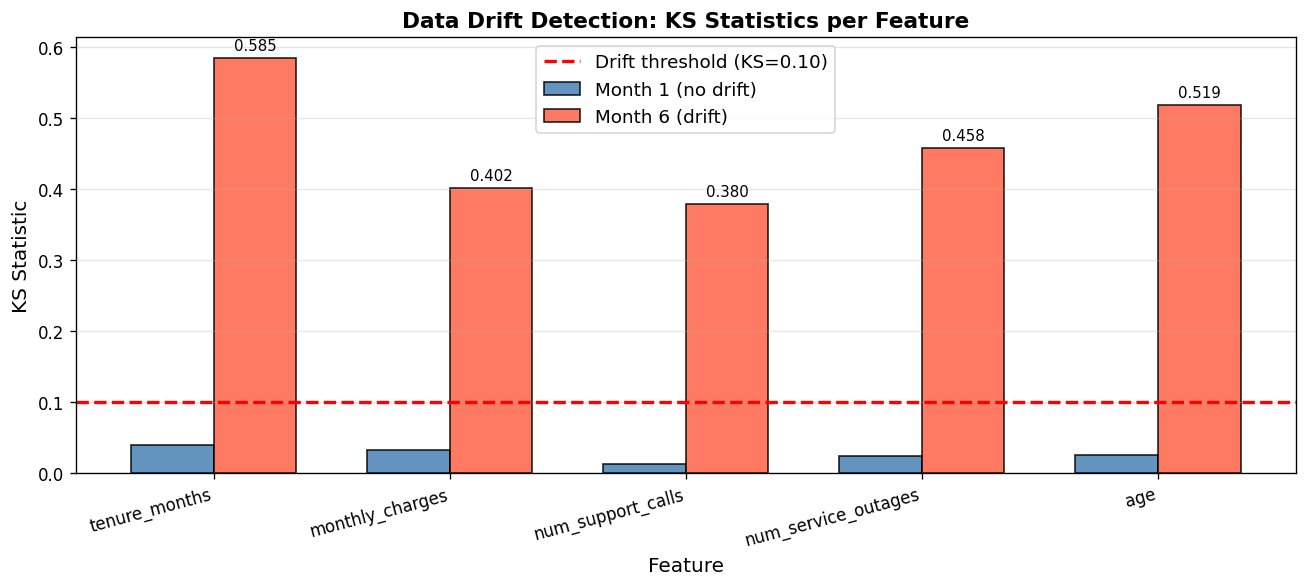


Features with significant drift at month 6: ['tenure_months', 'monthly_charges', 'num_support_calls', 'num_service_outages', 'age']
Action: Trigger retraining pipeline with recent production data.


In [7]:
# Simulate data drift: training distribution vs production data after 6 months
np.random.seed(99)
n_prod = 1000

# Training data reference distributions (from original dataset)
train_ref = {
    'tenure_months':       X_train['tenure_months'].values,
    'monthly_charges':     X_train['monthly_charges'].values,
    'num_support_calls':   X_train['num_support_calls'].values,
    'num_service_outages': X_train['num_service_outages'].values,
    'age':                 X_train['age'].values,
}

# Month 1 production: same distribution as training (no drift)
prod_month1 = {
    'tenure_months':       np.random.randint(1, 72, n_prod).astype(float),
    'monthly_charges':     np.random.uniform(20, 120, n_prod),
    'num_support_calls':   np.random.poisson(2.0, n_prod).astype(float),
    'num_service_outages': np.random.poisson(1.0, n_prod).astype(float),
    'age':                 np.random.randint(18, 75, n_prod).astype(float),
}

# Month 6 production: shifted distribution (competitor entered market)
# New customers: shorter tenure, higher charges, more outages, younger
prod_month6 = {
    'tenure_months':       np.random.randint(1, 30, n_prod).astype(float),   # shorter: new customers
    'monthly_charges':     np.random.uniform(60, 140, n_prod),               # higher: price hike
    'num_support_calls':   np.random.poisson(3.5, n_prod).astype(float),     # more: more frustrated
    'num_service_outages': np.random.poisson(2.5, n_prod).astype(float),     # more: infrastructure stress
    'age':                 np.random.randint(18, 45, n_prod).astype(float),  # younger: new demographic
}

features = list(train_ref.keys())

print("KS Test Results: Training vs Production Data")
print("=" * 75)
print(f"{'Feature':<25} {'Month-1 KS':>10} {'M1 p-val':>10} {'Month-6 KS':>12} {'M6 p-val':>10} {'Drift?':>8}")
print("-" * 75)

ks_stats_m1 = {}
ks_stats_m6 = {}

for feat in features:
    ks1, p1 = stats.ks_2samp(train_ref[feat], prod_month1[feat])
    ks6, p6 = stats.ks_2samp(train_ref[feat], prod_month6[feat])
    drift    = 'YES' if p6 < 0.05 else 'NO'
    ks_stats_m1[feat] = ks1
    ks_stats_m6[feat] = ks6
    print(f"{feat:<25} {ks1:>10.4f} {p1:>10.4f} {ks6:>12.4f} {p6:>10.6f} {drift:>8}")

# Bar chart of KS statistics
fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(features))
width  = 0.35
bars1  = ax.bar(x - width/2, [ks_stats_m1[f] for f in features], width,
                label='Month 1 (no drift)', color='steelblue', alpha=0.85, edgecolor='black')
bars6  = ax.bar(x + width/2, [ks_stats_m6[f] for f in features], width,
                label='Month 6 (drift)',    color='tomato',    alpha=0.85, edgecolor='black')

ax.axhline(y=0.10, color='red', linestyle='--', linewidth=2, label='Drift threshold (KS=0.10)')
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('KS Statistic', fontsize=12)
ax.set_title('Data Drift Detection: KS Statistics per Feature', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars6:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('drift_detection.png')
plt.show()

drifted = [f for f in features if stats.ks_2samp(train_ref[f], prod_month6[f])[1] < 0.05]
print(f"\nFeatures with significant drift at month 6: {drifted}")
print("Action: Trigger retraining pipeline with recent production data.")

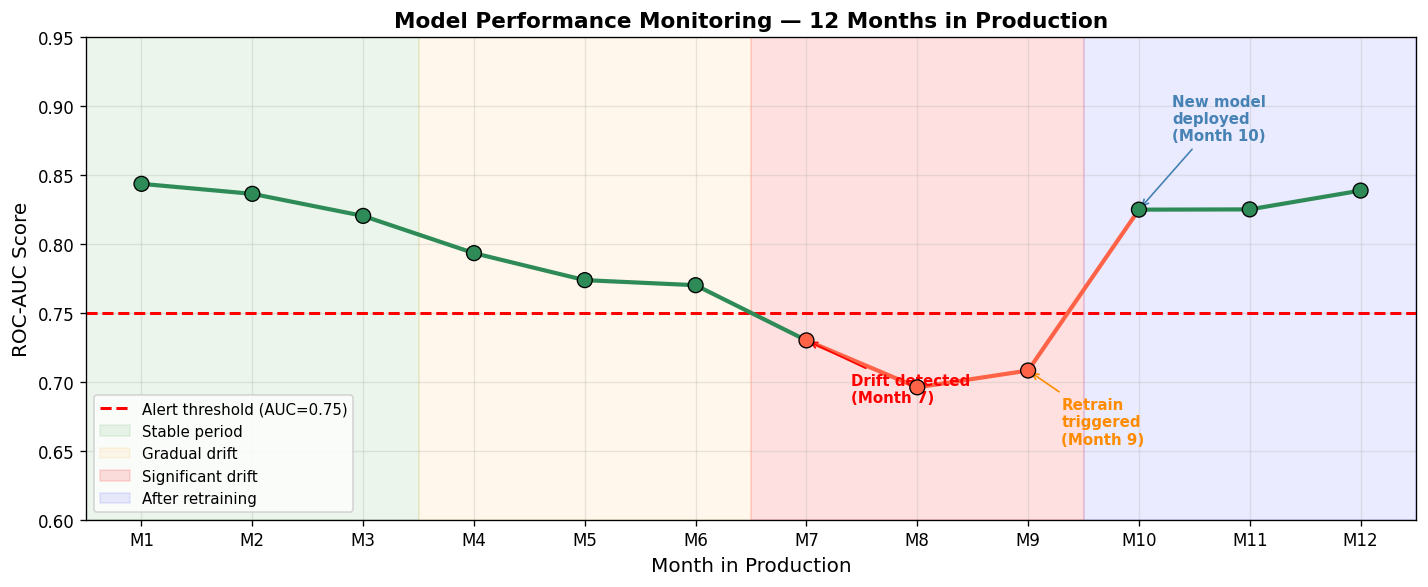

Performance Summary:
  Average AUC months 1-3  (stable)    : 0.833
  Average AUC months 4-6  (drift)     : 0.779
  Average AUC months 7-9  (severe)    : 0.711
  Average AUC months 10-12 (recovered): 0.829

Key insight: Without monitoring, the model degraded for 3+ months before anyone noticed.
With monitoring: alert fired at month 7, retrained by month 10. Business impact minimised.


In [8]:
# Simulate model performance monitoring over 12 months
np.random.seed(7)

months = list(range(1, 13))

# Simulate AUC trajectory
# Month 1-3: stable, high performance
# Month 4-6: slight drift begins, AUC starts declining
# Month 7-9: significant drift, AUC drops below threshold
# Month 10-12: retrain triggered at month 9, new model deployed at month 10, AUC recovers

auc_means = [0.83, 0.84, 0.82,   # months 1-3: stable
             0.79, 0.78, 0.77,   # months 4-6: slight decline
             0.73, 0.71, 0.70,   # months 7-9: significant drift
             0.82, 0.83, 0.84]   # months 10-12: recovered after retrain

auc_noise = [np.random.normal(m, 0.008) for m in auc_means]
auc_values = [max(0.60, min(0.99, v)) for v in auc_noise]

THRESHOLD = 0.75

fig, ax = plt.subplots(figsize=(12, 5))

# Color the line segments by performance zone
for i in range(len(months) - 1):
    color = 'tomato' if auc_values[i] < THRESHOLD else 'seagreen'
    ax.plot(months[i:i+2], auc_values[i:i+2], color=color, linewidth=2.5, zorder=3)

ax.scatter(months, auc_values, color=[
    'seagreen' if v >= THRESHOLD else 'tomato' for v in auc_values
], s=80, zorder=4, edgecolors='black', linewidths=0.8)

# Threshold line
ax.axhline(y=THRESHOLD, color='red', linestyle='--', linewidth=1.8,
           label=f'Alert threshold (AUC={THRESHOLD})', zorder=2)

# Shaded zones
ax.axvspan(0.5, 3.5,  alpha=0.08, color='green', label='Stable period')
ax.axvspan(3.5, 6.5,  alpha=0.08, color='orange', label='Gradual drift')
ax.axvspan(6.5, 9.5,  alpha=0.12, color='red', label='Significant drift')
ax.axvspan(9.5, 12.5, alpha=0.08, color='blue', label='After retraining')

# Annotations
ax.annotate('Drift detected\n(Month 7)',
            xy=(7, auc_values[6]), xytext=(7.4, 0.685),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=9, fontweight='bold')
ax.annotate('Retrain\ntriggered\n(Month 9)',
            xy=(9, auc_values[8]), xytext=(9.3, 0.655),
            arrowprops=dict(arrowstyle='->', color='darkorange'),
            color='darkorange', fontsize=9, fontweight='bold')
ax.annotate('New model\ndeployed\n(Month 10)',
            xy=(10, auc_values[9]), xytext=(10.3, 0.875),
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            color='steelblue', fontsize=9, fontweight='bold')

ax.set_xlabel('Month in Production', fontsize=12)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('Model Performance Monitoring — 12 Months in Production', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0.60, 0.95)
ax.set_xticks(months)
ax.set_xticklabels([f'M{m}' for m in months])
ax.legend(fontsize=9, loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_monitoring.png')
plt.show()

print("Performance Summary:")
print(f"  Average AUC months 1-3  (stable)    : {np.mean(auc_values[0:3]):.3f}")
print(f"  Average AUC months 4-6  (drift)     : {np.mean(auc_values[3:6]):.3f}")
print(f"  Average AUC months 7-9  (severe)    : {np.mean(auc_values[6:9]):.3f}")
print(f"  Average AUC months 10-12 (recovered): {np.mean(auc_values[9:12]):.3f}")
print()
print("Key insight: Without monitoring, the model degraded for 3+ months before anyone noticed.")
print("With monitoring: alert fired at month 7, retrained by month 10. Business impact minimised.")

---

# Lesson 7: CI/CD for Machine Learning

## What Is CI/CD and Why Does ML Need It?

**CI/CD** stands for Continuous Integration / Continuous Deployment. In software engineering, CI/CD pipelines automatically test code and deploy it when tests pass — no human has to manually push a button.

ML needs the same thing, but the "tests" are different:
- Instead of unit tests: data validation, model quality checks
- Instead of deploying code: promoting a new model version to production
- Instead of code review: model evaluation and A/B testing

## The ML CI/CD Pipeline

```
TRIGGER: Monday 2am (scheduled) OR drift alert detected
         │
         ▼
┌─────────────────────────────────────────────────────────────────┐
│  STEP 1: DATA VALIDATION                                        │
│  - Check data schema (right columns, right types)               │
│  - Check for nulls, outliers, impossible values                 │
│  - Run KS tests vs training distribution                        │
│  - FAIL FAST: if data looks corrupt, stop here, alert team      │
└─────────────────────┬───────────────────────────────────────────┘
                       │ PASS
                       ▼
┌─────────────────────────────────────────────────────────────────┐
│  STEP 2: MODEL TRAINING                                         │
│  - Retrain on last 6 months of data (rolling window)            │
│  - Log everything to MLflow (params, metrics, artifacts)        │
│  - Save model to MLflow registry as new version (Staging)       │
└─────────────────────┬───────────────────────────────────────────┘
                       │
                       ▼
┌─────────────────────────────────────────────────────────────────┐
│  STEP 3: MODEL EVALUATION                                       │
│  - Evaluate new model on held-out validation set                │
│  - Compare: new AUC vs current production AUC                   │
│  - Check: is new model at least 1% better than production?      │
│  - Check: no regression on important demographic slices         │
└─────────────────────┬───────────────────────────────────────────┘
                       │ BETTER
                       ▼
┌─────────────────────────────────────────────────────────────────┐
│  STEP 4: A/B TEST (optional, for high-stakes models)            │
│  - Route 10% of traffic to new model, 90% to production         │
│  - Monitor for 1-7 days: is new model actually better live?     │
│  - Statistical test: is improvement significant?                │
└─────────────────────┬───────────────────────────────────────────┘
                       │ SIGNIFICANT
                       ▼
┌─────────────────────────────────────────────────────────────────┐
│  STEP 5: PROMOTION                                              │
│  - Promote new model: Staging → Production                      │
│  - Archive old production model                                 │
│  - Send Slack notification to team: "Model v3 is now live"      │
└─────────────────────────────────────────────────────────────────┘
```

## GitHub Actions YAML (Example Structure)

This is what the automation looks like as code. Each step above becomes a job in the pipeline.

```yaml
# .github/workflows/ml_pipeline.yml
# NOTE: This is an illustrative example — not runnable in this notebook.

name: ML Retraining Pipeline

on:
  schedule:
    - cron: '0 2 * * 1'   # Every Monday at 2am UTC
  workflow_dispatch:        # Also allow manual trigger from GitHub UI
    inputs:
      reason:
        description: 'Reason for manual retrain (e.g. drift alert)'
        required: true

jobs:
  ml-pipeline:
    runs-on: ubuntu-latest
    steps:

      - name: Checkout code
        uses: actions/checkout@v3

      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: '3.11'

      - name: Install dependencies
        run: pip install -r requirements.txt

      - name: Step 1 - Data Validation
        run: python scripts/validate_data.py
        # Fails the whole pipeline if data quality checks fail

      - name: Step 2 - Train Model
        run: python scripts/train.py --experiment churn_prediction
        # Logs to MLflow, saves new model to Staging in registry

      - name: Step 3 - Evaluate vs Production
        run: python scripts/evaluate.py --min-improvement 0.01
        # Compares new Staging model vs current Production model
        # Fails if new model is not better

      - name: Step 4 - Promote to Production
        if: success()
        run: python scripts/promote.py --model ChurnPredictor --stage Production
        # Only runs if all previous steps passed

      - name: Step 5 - Notify Team
        if: always()
        run: python scripts/notify_slack.py --status ${{ job.status }}
```

This pipeline runs every Monday at 2am automatically. If it succeeds, the team wakes up to a new, better model already in production. If it fails, they get a Slack alert and the old model stays live.

A/B Test Results: Model A (Production) vs Model B (Challenger)
                                    Model A      Model B
-------------------------------------------------------
Total customers served                  500          500
High-risk flags raised                  200          220
Flagged customers retained              134          162
Flagged customers churned                66           58
Retention rate (flagged)              67.0%        73.6%

Chi-square statistic : 1.9099
P-value              : 0.1670
Degrees of freedom   : 1

Decision: KEEP Model A in Production
Reason  : Difference not statistically significant (p=0.1670 >= 0.05)

Business impact of choosing Model B:
  Extra customers retained per 1000: 28
  Annual revenue protected (est.)  : $23,520


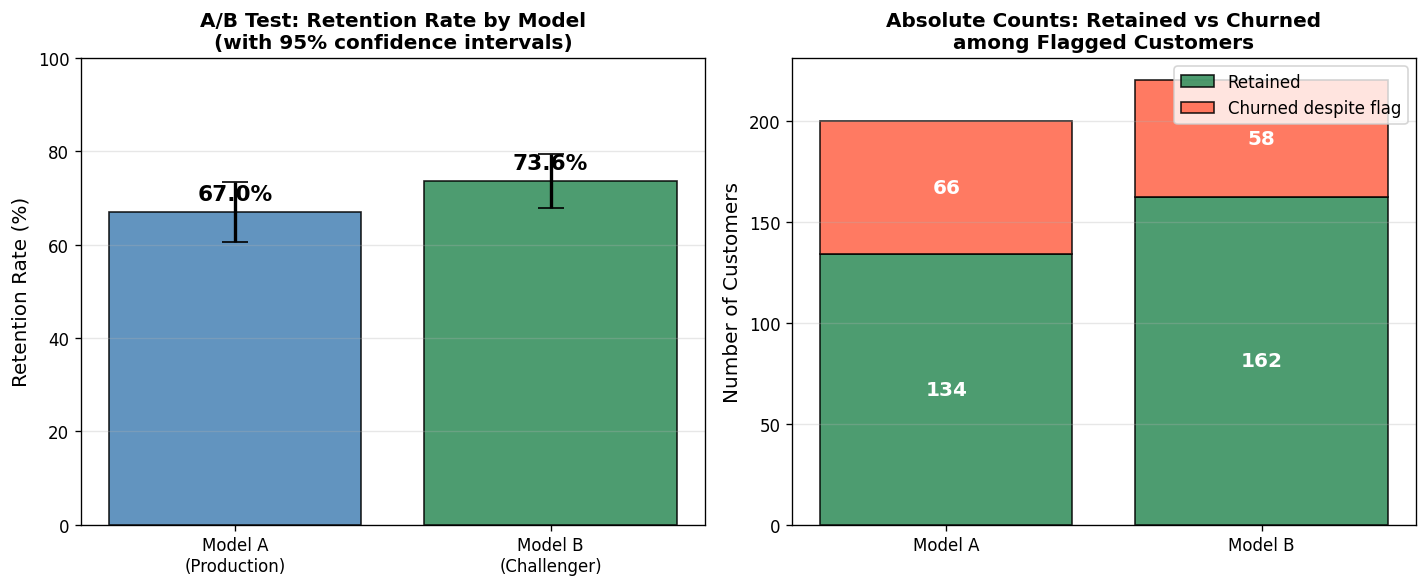

In [9]:
# A/B Test Simulation: Model A (current production) vs Model B (challenger)
from scipy.stats import chi2_contingency
np.random.seed(42)

# Setup
n_per_group = 500   # 500 customers per model, 1000 total

# Model A: current production model (RF_100_d5), AUC ≈ 0.81
# Model B: challenger (RF_200_d10 + recent data), AUC ≈ 0.85
# After 30 days: observe which customers actually churned / were retained

# Model A identifies 40% of its 500 as high-risk (predicted churners)
# Of those flagged by Model A, 67% were successfully retained by the retention team
# Model B identifies 44% as high-risk (better recall)
# Of those flagged by Model B, 74% were successfully retained

# Model A results
a_flagged       = int(n_per_group * 0.40)   # 200 flagged as high-risk
a_retained      = int(a_flagged * 0.67)     # 134 actually retained
a_not_retained  = a_flagged - a_retained    # 66 churned anyway
a_not_flagged   = n_per_group - a_flagged   # 300 not flagged

# Model B results
b_flagged       = int(n_per_group * 0.44)   # 220 flagged as high-risk
b_retained      = int(b_flagged * 0.74)     # 163 actually retained
b_not_retained  = b_flagged - b_retained    # 57 churned anyway
b_not_flagged   = n_per_group - b_flagged   # 280 not flagged

print("A/B Test Results: Model A (Production) vs Model B (Challenger)")
print("=" * 65)
print(f"{'':30} {'Model A':>12} {'Model B':>12}")
print("-" * 55)
print(f"{'Total customers served':30} {n_per_group:>12} {n_per_group:>12}")
print(f"{'High-risk flags raised':30} {a_flagged:>12} {b_flagged:>12}")
print(f"{'Flagged customers retained':30} {a_retained:>12} {b_retained:>12}")
print(f"{'Flagged customers churned':30} {a_not_retained:>12} {b_not_retained:>12}")
print(f"{'Retention rate (flagged)':30} {a_retained/a_flagged*100:>11.1f}% {b_retained/b_flagged*100:>11.1f}%")

# Chi-square test: is the difference statistically significant?
# Contingency table: [retained, churned] for each model
observed = np.array([[a_retained, a_not_retained],
                     [b_retained, b_not_retained]])

chi2, p_val, dof, expected = chi2_contingency(observed)

print()
print(f"Chi-square statistic : {chi2:.4f}")
print(f"P-value              : {p_val:.4f}")
print(f"Degrees of freedom   : {dof}")
print()

if p_val < 0.05:
    decision = "PROMOTE Model B to Production"
    reason   = f"Model B is significantly better (p={p_val:.4f} < 0.05)"
else:
    decision = "KEEP Model A in Production"
    reason   = f"Difference not statistically significant (p={p_val:.4f} >= 0.05)"

print(f"Decision: {decision}")
print(f"Reason  : {reason}")

# Business impact calculation
extra_retained = b_retained - a_retained
revenue_per_customer = 70  # average monthly charge
annual_impact = extra_retained * revenue_per_customer * 12
print(f"\nBusiness impact of choosing Model B:")
print(f"  Extra customers retained per 1000: {extra_retained}")
print(f"  Annual revenue protected (est.)  : ${annual_impact:,.0f}")

# Visualize A/B test results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: retention rates with error bars (Wilson confidence interval approximation)
rates      = [a_retained/a_flagged, b_retained/b_flagged]
counts     = [a_flagged, b_flagged]
# Standard error for proportion
se         = [np.sqrt(r*(1-r)/n) for r, n in zip(rates, counts)]
ci_95      = [1.96 * s for s in se]

colors_ab  = ['steelblue', 'seagreen']
labels_ab  = ['Model A\n(Production)', 'Model B\n(Challenger)']
bars_ab    = axes[0].bar(labels_ab, [r*100 for r in rates],
                         color=colors_ab, alpha=0.85, edgecolor='black',
                         yerr=[ci*100 for ci in ci_95], capsize=8,
                         error_kw=dict(elinewidth=2, ecolor='black'))

axes[0].set_ylabel('Retention Rate (%)', fontsize=12)
axes[0].set_title('A/B Test: Retention Rate by Model\n(with 95% confidence intervals)', fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)
for bar, rate in zip(bars_ab, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2.5,
                 f'{rate*100:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Stacked bar: retained vs churned for each model
model_labels = ['Model A', 'Model B']
retained_vals = [a_retained, b_retained]
churned_vals  = [a_not_retained, b_not_retained]
x_ab          = np.arange(2)

axes[1].bar(x_ab, retained_vals, label='Retained', color='seagreen', alpha=0.85, edgecolor='black')
axes[1].bar(x_ab, churned_vals,  bottom=retained_vals, label='Churned despite flag',
            color='tomato', alpha=0.85, edgecolor='black')
axes[1].set_ylabel('Number of Customers', fontsize=12)
axes[1].set_title('Absolute Counts: Retained vs Churned\namong Flagged Customers', fontweight='bold')
axes[1].set_xticks(x_ab)
axes[1].set_xticklabels(model_labels)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

for i, (ret, churn) in enumerate(zip(retained_vals, churned_vals)):
    axes[1].text(i, ret/2, str(ret), ha='center', va='center', fontweight='bold', color='white', fontsize=12)
    axes[1].text(i, ret + churn/2, str(churn), ha='center', va='center', fontweight='bold', color='white', fontsize=12)

plt.tight_layout()
plt.savefig('ab_test.png')
plt.show()

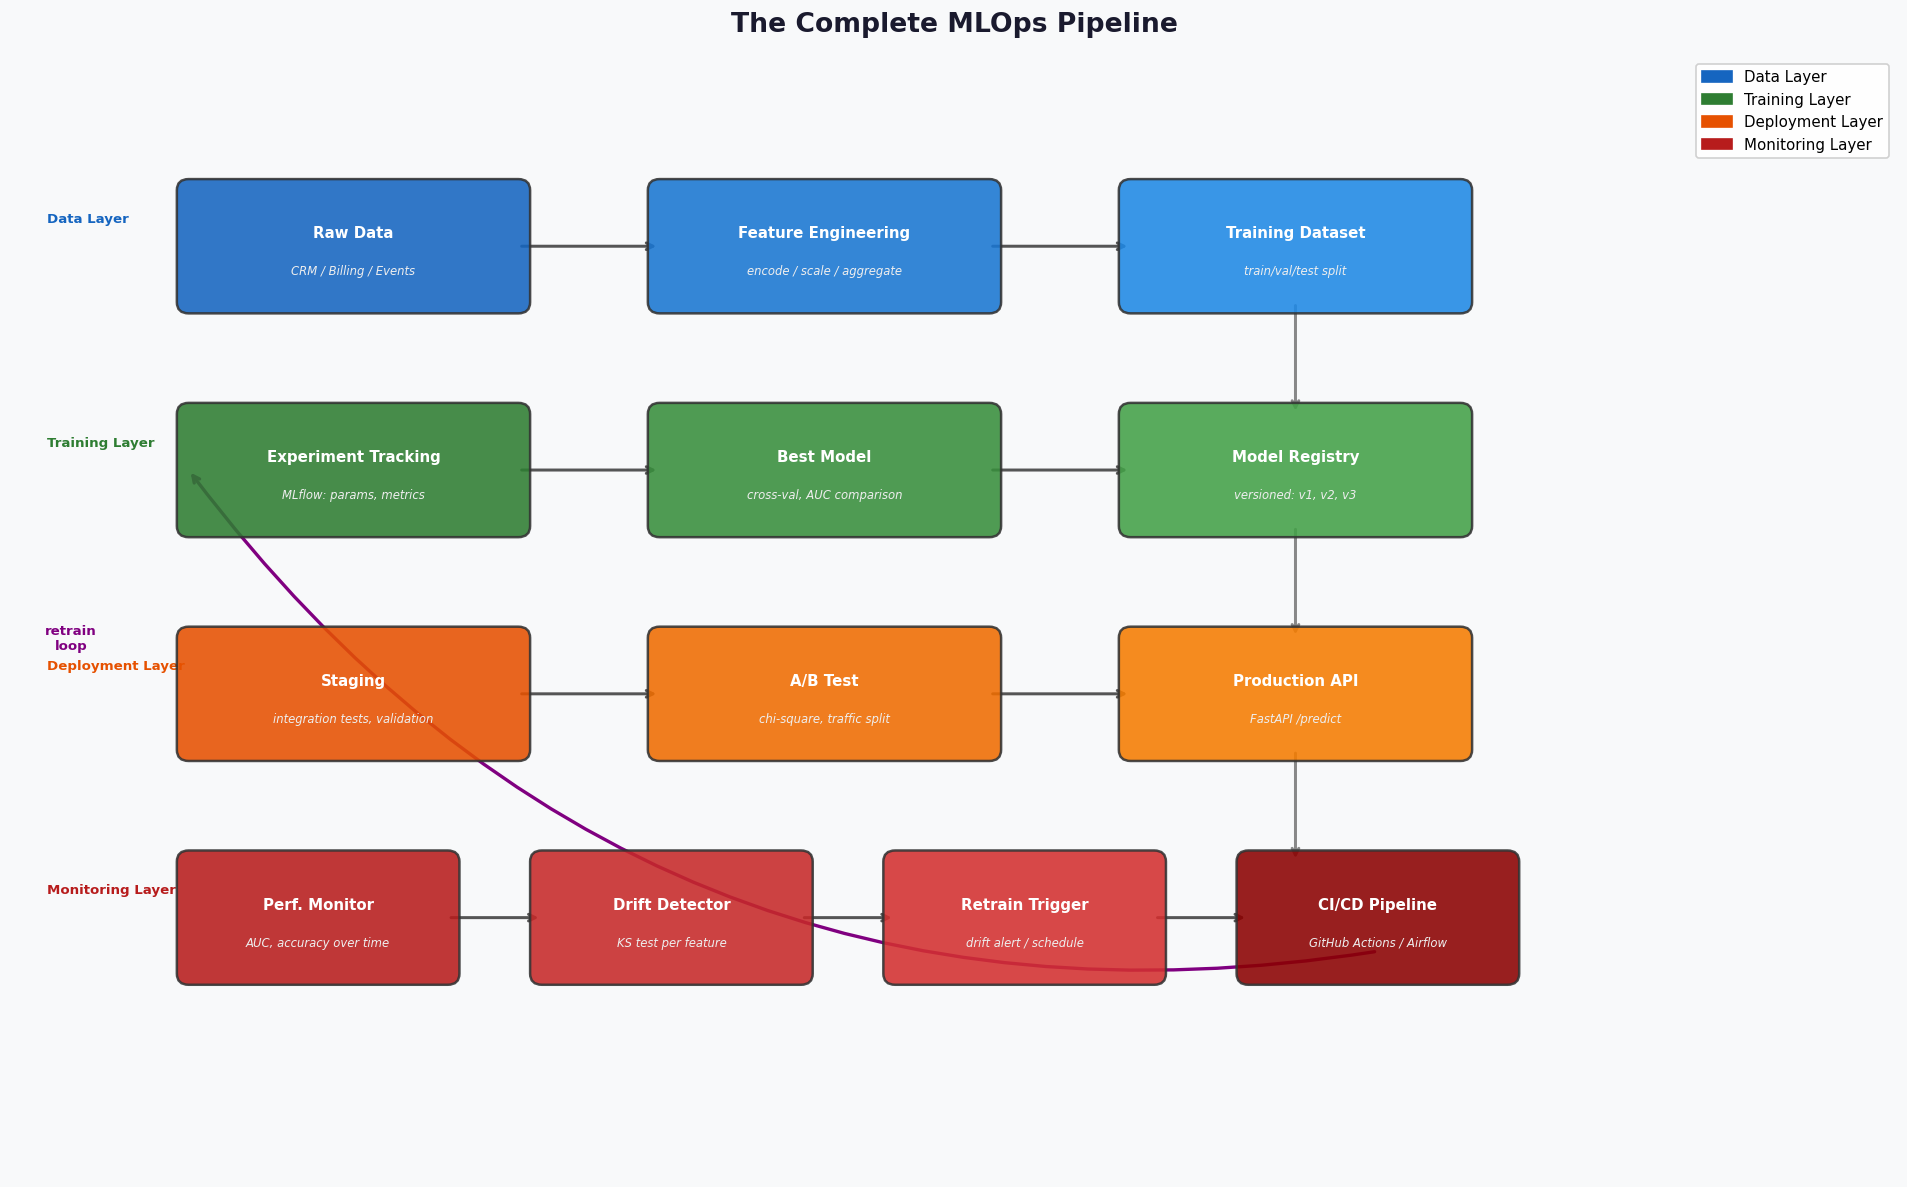

MLOps pipeline diagram saved as mlops_pipeline.png


In [10]:
# Complete MLOps Pipeline Summary Diagram
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

def draw_box(ax, x, y, w, h, label, sublabel, color, fontsize=9):
    box = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.1',
        linewidth=1.5, edgecolor='#333333',
        facecolor=color, alpha=0.88, zorder=3
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h*0.62, label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='white', zorder=4)
    ax.text(x + w/2, y + h*0.28, sublabel,
            ha='center', va='center', fontsize=7,
            color='#eeeeee', zorder=4, style='italic')

def draw_arrow(ax, x1, y1, x2, y2, color='#555555'):
    ax.annotate('',
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.8),
        zorder=2
    )

# Row labels
row_labels = ['Data Layer', 'Training Layer', 'Deployment Layer', 'Monitoring Layer']
row_y      = [8.0, 6.0, 4.0, 2.0]
row_colors = ['#1565C0', '#2E7D32', '#E65100', '#B71C1C']
for label, y, color in zip(row_labels, row_y, row_colors):
    ax.text(0.3, y + 0.55, label, ha='left', va='center',
            fontsize=8, fontweight='bold', color=color, rotation=0)

# ROW 1: Data
blue_dark  = '#1565C0'
blue_mid   = '#1976D2'
blue_light = '#1E88E5'
draw_box(ax, 1.5, 7.8, 2.8, 1.0, 'Raw Data', 'CRM / Billing / Events', blue_dark)
draw_box(ax, 5.5, 7.8, 2.8, 1.0, 'Feature Engineering', 'encode / scale / aggregate', blue_mid)
draw_box(ax, 9.5, 7.8, 2.8, 1.0, 'Training Dataset', 'train/val/test split', blue_light)
draw_arrow(ax, 4.3, 8.3, 5.5, 8.3)
draw_arrow(ax, 8.3, 8.3, 9.5, 8.3)

# ROW 2: Training
green_dark  = '#2E7D32'
green_mid   = '#388E3C'
green_light = '#43A047'
draw_box(ax, 1.5, 5.8, 2.8, 1.0, 'Experiment Tracking', 'MLflow: params, metrics', green_dark)
draw_box(ax, 5.5, 5.8, 2.8, 1.0, 'Best Model', 'cross-val, AUC comparison', green_mid)
draw_box(ax, 9.5, 5.8, 2.8, 1.0, 'Model Registry', 'versioned: v1, v2, v3', green_light)
draw_arrow(ax, 4.3, 6.3, 5.5, 6.3)
draw_arrow(ax, 8.3, 6.3, 9.5, 6.3)
# Connect data to training
draw_arrow(ax, 10.9, 7.8, 10.9, 6.8, color='#888888')

# ROW 3: Deployment
orange_dark  = '#E65100'
orange_mid   = '#EF6C00'
orange_light = '#F57C00'
draw_box(ax, 1.5, 3.8, 2.8, 1.0, 'Staging', 'integration tests, validation', orange_dark)
draw_box(ax, 5.5, 3.8, 2.8, 1.0, 'A/B Test', 'chi-square, traffic split', orange_mid)
draw_box(ax, 9.5, 3.8, 2.8, 1.0, 'Production API', 'FastAPI /predict', orange_light)
draw_arrow(ax, 4.3, 4.3, 5.5, 4.3)
draw_arrow(ax, 8.3, 4.3, 9.5, 4.3)
# Connect registry to staging
draw_arrow(ax, 10.9, 5.8, 10.9, 4.8, color='#888888')

# ROW 4: Monitoring
red_dark  = '#B71C1C'
red_mid   = '#C62828'
red_light = '#D32F2F'
draw_box(ax, 1.5, 1.8, 2.2, 1.0, 'Perf. Monitor', 'AUC, accuracy over time', red_dark)
draw_box(ax, 4.5, 1.8, 2.2, 1.0, 'Drift Detector', 'KS test per feature', red_mid)
draw_box(ax, 7.5, 1.8, 2.2, 1.0, 'Retrain Trigger', 'drift alert / schedule', red_light)
draw_box(ax, 10.5, 1.8, 2.2, 1.0, 'CI/CD Pipeline', 'GitHub Actions / Airflow', '#8B0000')
draw_arrow(ax, 3.7, 2.3, 4.5, 2.3)
draw_arrow(ax, 6.7, 2.3, 7.5, 2.3)
draw_arrow(ax, 9.7, 2.3, 10.5, 2.3)
# Connect prod API to monitoring
draw_arrow(ax, 10.9, 3.8, 10.9, 2.8, color='#888888')
# Loop: retrain trigger back to experiment tracking (the feedback loop)
ax.annotate('',
    xy=(1.5, 6.3), xytext=(11.6, 2.0),
    arrowprops=dict(arrowstyle='->', color='purple', lw=2.0,
                    connectionstyle='arc3,rad=-0.3'),
    zorder=2
)
ax.text(0.5, 4.8, 'retrain\nloop', ha='center', va='center',
        fontsize=8, color='purple', fontweight='bold')

# Title and legend
ax.set_title('The Complete MLOps Pipeline', fontsize=16, fontweight='bold',
             color='#1a1a2e', pad=15)

legend_patches = [
    mpatches.Patch(color=blue_dark,   label='Data Layer'),
    mpatches.Patch(color=green_dark,  label='Training Layer'),
    mpatches.Patch(color=orange_dark, label='Deployment Layer'),
    mpatches.Patch(color=red_dark,    label='Monitoring Layer'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9,
          framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.savefig('mlops_pipeline.png', bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("MLOps pipeline diagram saved as mlops_pipeline.png")

---

# Series Complete — All 6 Modules in One Table

You have completed the full Fine-Tuning & ML Fundamentals series. Here is everything you learned:

| Module | Topic | Core Skill | Key Tool |
|---|---|---|---|
| **Module 1** | Traditional Machine Learning | Supervised learning, EDA, model evaluation | scikit-learn |
| **Module 2** | Deep Learning Fundamentals | Neural networks, backpropagation, regularisation | PyTorch |
| **Module 3** | Transfer Learning | Feature extraction, fine-tuning pre-trained models | HuggingFace Transformers |
| **Module 4** | PEFT / LoRA | Parameter-efficient fine-tuning, adapter layers | PEFT, bitsandbytes |
| **Module 5** | RLHF | Reward modelling, PPO, aligning LLMs to human preferences | TRL |
| **Module 6** | MLOps | Experiment tracking, serving, monitoring, CI/CD | MLflow, FastAPI |

Each module built on the previous one. The churn dataset from Module 1 became the model we deployed in Module 6. That is exactly how real ML projects work — end to end.

---

# 4 MLOps Interview Questions You Can Now Answer

---

**Q1: What is data drift and how do you detect it?**

> Data drift (covariate shift) is when the statistical distribution of input features in production diverges from the distribution the model was trained on. This happens because the world changes — new customer demographics, market conditions, product changes. The model was trained on a frozen snapshot of the past. To detect it, I compute the Kolmogorov-Smirnov (KS) statistic between the training distribution and recent production data for each numeric feature. A KS statistic above 0.10 or a p-value below 0.05 triggers a review. For categorical features I use chi-square tests. I set up automated daily monitoring jobs that alert the team when drift is detected.

---

**Q2: How do you version ML models in production?**

> I use the MLflow Model Registry. Every trained model gets logged as a new version (v1, v2, v3). Each version goes through stages: after training it enters Staging, where it is evaluated on held-out data and tested in an A/B test. If it outperforms the current Production model, it is promoted to Production and the old version is Archived. The registry keeps the full lineage — which run produced the model, what parameters it used, what metrics it achieved, who promoted it and when. This means I can roll back to any previous version in seconds by changing the stage label.

---

**Q3: Walk me through your ML deployment process.**

> After training and selecting the best model via experiment tracking in MLflow, I register it to the Model Registry in Staging. I then run an automated evaluation pipeline that compares it against the current Production model on a fixed validation set. If the new model improves AUC by at least 1%, I promote it to a canary deployment — routing 10% of live traffic to it while the old model handles 90%. I monitor both in parallel for 3-7 days, collecting live performance metrics. If the improvement holds up with statistical significance (chi-square or z-test, p < 0.05), I promote it fully to Production and archive the old version. The whole process is orchestrated by a GitHub Actions CI/CD pipeline that runs on a weekly schedule or when a drift alert fires.

---

**Q4: How do you decide when to retrain a model?**

> I use two triggers in parallel. The first is scheduled retraining — typically weekly or monthly on a rolling window of the most recent data, regardless of detected drift. This keeps the model fresh even if we have not explicitly detected a problem. The second is event-driven retraining: if the daily drift monitoring detects KS statistics above 0.20 on multiple features, or if the production AUC drops below our defined alert threshold (typically 5% degradation from baseline), an alert fires immediately and triggers an unscheduled retrain. Before promoting the retrained model, it must pass a comparison test showing it is actually better — otherwise the retrain job just exits without deploying anything. This prevents a degraded retrain from making things worse.

---

# What Is Next — Advanced Topics to Explore

This series gave you the complete foundation. Here is what comes after:

| Advanced Topic | What It Is | Why It Matters |
|---|---|---|
| **LLMOps** | MLOps specifically for Large Language Models | LLMs have unique deployment challenges: latency, cost, hallucinations, prompt versioning |
| **Vector Databases** | Databases optimised for embedding similarity search | Foundation of semantic search, RAG, recommendation systems |
| **RAG Pipelines** | Retrieval-Augmented Generation | Make LLMs answer from your private company data, not just training data |
| **Multi-Modal Models** | Models that combine text, images, audio | GPT-4 Vision, Gemini — the frontier of production AI |
| **AI Agents** | LLMs that autonomously use tools and make decisions | Automate complex workflows that previously required human judgment |
| **Feature Stores** | Centralised repository for ML features | Reuse features across models, ensure train/serve consistency |
| **Model Explainability** | SHAP, LIME, counterfactual explanations | Required for regulated industries (banking, healthcare, insurance) |

---

# Congratulations

You have completed all 6 modules of the Fine-Tuning & ML Fundamentals series.

Most ML candidates can talk about training a model. Very few can talk confidently about:
- How experiments are tracked and reproduced
- How models are versioned and rolled back in production
- How APIs are built to serve predictions at scale
- How drift is detected and retraining is triggered automatically
- How A/B tests are run to validate new model versions statistically

You now can. That puts you ahead of 80% of candidates applying for ML Engineering roles.

The gap between a data scientist who builds notebooks and an ML Engineer who ships reliable production systems is exactly what you have learned in this module.

---

*Module 6 of 6 — Fine-Tuning & ML Fundamentals Series*  
*Series complete.*